In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets.mnist import MNIST
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import numpy as np
import random
import os
import pandas as pd
from xor import XOR
# from GraphRicciCurvature.OllivierRicci import OllivierRicci
import networkx as nx
import networkit as nk

import sys
sys.path.append("..")

import tools.utils as utils
from tools.small_model import FC_MD
from RicciCurvature.OllivierRicci import OllivierRicci

In [2]:
seed = 59

# set random seed
random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False


os.environ['CUDA_VISIBLE_DEVICES'] = '1' 
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")
device = 'cpu'

Using cuda device


In [6]:
w_avg = np.array([[0,2.,3,4],[1,0,2,0]])


w_avg[w_avg != 0] = 1/w_avg[w_avg != 0]

print(w_avg)

[[0.         0.5        0.33333333 0.25      ]
 [1.         0.         0.5        0.        ]]


In [6]:
x = torch.tensor([[0.,0.], [0.,1.], [1.,0.], [1.,1.]])
y = torch.tensor([0.,1.,1.,0.])

In [7]:
model = XOR().to(device)

In [3]:
class DataSet(Dataset):
    def __init__(self, x, y):
        self.len = x.shape[0]
        self.x_data = x 
        self.y_data = y 

    def __getitem__(self, index):
        return self.x_data[index], self.y_data[index]

    def __len__(self):
        return self.len

In [9]:
dataset = DataSet(x, y)
loader = DataLoader(dataset=dataset, batch_size=1, shuffle=False, num_workers=1)

In [10]:
model.eval()
for i, (d, label) in enumerate(loader):
    
    d = d.to(device)
    output = model.edge_w_batch(d)
    
    output = output.cpu().detach().numpy() 
    if (i == 0):
        e_weights = output
    else:
        e_weights = np.vstack((e_weights,output))
        
print(e_weights)
print(e_weights.shape)

[[ 0.  0.  0.  0.  0.  0.  0.  0.  0. -0.  0.  0.]
 [ 0.  0.  0.  0.  1.  1.  1.  5.  1. -0.  0.  5.]
 [ 1.  0.  1.  1.  0.  0.  0.  0.  1. -0.  0.  1.]
 [ 1.  0.  1.  1.  1.  1.  1.  5.  2. -0.  0.  6.]]
(4, 12)


In [11]:
w_avg = np.mean(e_weights, axis=0)
print(w_avg)

w_avg = np.abs(w_avg) 

[0.5 0.  0.5 0.5 0.5 0.5 0.5 2.5 1.  0.  0.  3. ]


In [12]:
nodes_num = 7
dims = [2,4,1]

# build adjacent matrix
adjacent_m = np.zeros((nodes_num, nodes_num), dtype=np.float32)

layer_num = len(dims)
cur_s_col = dims[0]
cur_e_col = dims[0] + dims[1]

cur_layer = 1
start_col = 0
end_col = dims[1]

for i in range(nodes_num - dims[layer_num-1]):
    # print(f'i : {i}, start col : {cur_s_col}, end_col : {cur_e_col}, from {start_col} to {end_col}')
    adjacent_m[i, cur_s_col : cur_e_col] = w_avg[start_col : end_col]
    
    if (cur_layer < layer_num-1 and i == cur_s_col - 1):
        cur_layer += 1
        start_col = end_col
        end_col = end_col + dims[cur_layer]
        cur_s_col = cur_e_col
        cur_e_col = cur_e_col + dims[cur_layer]
    else:
        start_col = end_col
        end_col = end_col + dims[cur_layer]
        
print(adjacent_m)

adjacent_m[adjacent_m>0] = 1.
            

[[0.  0.  0.5 0.  0.5 0.5 0. ]
 [0.  0.  0.5 0.5 0.5 2.5 0. ]
 [0.  0.  0.  0.  0.  0.  1. ]
 [0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.  0.  0.  3. ]
 [0.  0.  0.  0.  0.  0.  0. ]]


In [2]:
def show_results(G, curvature="ricciCurvature"):

    # Print the first five results
    for n1,n2 in list(G.edges()):  
        print(f'Edges between nodes {n1} and {n2}, edge weight is {G[n1][n2]["weight"]}, curvature is {G[n1][n2][curvature]}..')


In [4]:
matrix = np.zeros((6,6), dtype=np.float32)

matrix[0,2] = 1
matrix[0,3] = 2
matrix[1,2] = 5
matrix[1,3] = 2
matrix[2,4] = 0
matrix[3,4] = 2
matrix[4,5] = 3


G = nx.from_numpy_array(matrix, create_using=nx.DiGraph)
orf = OllivierRicci(G, alpha=0., verbose="ERROR")
# orf.compute_ricci_flow(iterations=100)
orf.compute_ricci_curvature()
G1 = orf.G.copy()


_Gk = nk.nxadapter.nx2nk(G1, weightAttr='weight')

    
print(_Gk.weight(2, 2))
show_results(G1, "ricciCurvature")

/home/tans5/anaconda3/envs/COMM/lib/python3.10/site-packages/ot/lp/__init__.py:575: UserWarning: Input histogram consists of integer. The transport plan will be casted accordingly, possibly resulting in a loss of precision. If this behaviour is unwanted, please make sure your input histogram consists of floating point elements.
  return f(b)
/home/tans5/anaconda3/envs/COMM/lib/python3.10/site-packages/ot/lp/__init__.py:575: UserWarning: Input histogram consists of integer. The transport plan will be casted accordingly, possibly resulting in a loss of precision. If this behaviour is unwanted, please make sure your input histogram consists of floating point elements.
  return f(b)
/home/tans5/anaconda3/envs/COMM/lib/python3.10/site-packages/ot/lp/__init__.py:575: UserWarning: Input histogram consists of integer. The transport plan will be casted accordingly, possibly resulting in a loss of precision. If this behaviour is unwanted, please make sure your input histogram consists of floatin

0.0
Edges between nodes 0 and 2, edge weight is 1.0, curvature is 0.0..
Edges between nodes 0 and 3, edge weight is 2.0, curvature is -1.0..
Edges between nodes 1 and 2, edge weight is 5.0, curvature is 0.0..
Edges between nodes 1 and 3, edge weight is 2.0, curvature is -1.0..
Edges between nodes 3 and 4, edge weight is 2.0, curvature is -2.5..
Edges between nodes 4 and 5, edge weight is 3.0, curvature is -0.6666666666666667..


In [8]:
matrix = np.zeros((11,11), dtype=np.int32)

matrix[0,1] = 1
matrix[0,2] = 1
matrix[0,3] = 1
matrix[0,4] = 1
matrix[1,2] = 1
matrix[1,3] = 1
matrix[1,4] = 1
matrix[2,3] = 1
matrix[2,4] = 1
matrix[3,4] = 1
matrix[4,5] = 1
matrix[5,6] = 1
matrix[5,8] = 1
matrix[6,7] = 1
matrix[6,9] = 1
matrix[7,10] = 1
matrix[8,9] = 1
matrix[9,10] = 1

G = nx.from_numpy_array(matrix, create_using=nx.DiGraph)
orf = OllivierRicci(G, alpha=0.5, verbose="TRACE")
# orf.compute_ricci_flow(iterations=100)
orf.compute_ricci_curvature()
G1 = orf.G.copy()
show_results(G1, "ricciCurvature")

for 1 to 4, x is [0.5 0.5], source nbr is [0, 1], y is [0.5 0.5], target nbr is [5, 4], shorest path is [[2. 1.]
 [2. 1.]]
for 0 to 3, x is [1], source nbr is [0], y is [0.5 0.5], target nbr is [4, 3], shorest path is [[1. 1.]]
for 1 to 3, x is [0.5 0.5], source nbr is [0, 1], y is [0.5 0.5], target nbr is [4, 3], shorest path is [[1. 1.]
 [1. 1.]]
for 0 to 4, x is [1], source nbr is [0], y is [0.5 0.5], target nbr is [5, 4], shorest path is [[2. 1.]]
for 4 to 5, x is [0.125 0.125 0.125 0.125 0.5  ], source nbr is [0, 1, 2, 3, 4], y is [0.25 0.25 0.5 ], target nbr is [6, 8, 5], shorest path is [[3. 3. 2.]
 [3. 3. 2.]
 [3. 3. 2.]
 [3. 3. 2.]
 [2. 2. 1.]]
for 0 to 2, x is [1], source nbr is [0], y is [0.25 0.25 0.5 ], target nbr is [3, 4, 2], shorest path is [[1. 1. 1.]]
for 0 to 1, x is [1], source nbr is [0], y is [0.16666667 0.16666667 0.16666667 0.5       ], target nbr is [2, 3, 4, 1], shorest path is [[1. 1. 1. 1.]]
for 1 to 2, x is [0.5 0.5], source nbr is [0, 1], y is [0.25 0.25 0

/home/tans5/anaconda3/envs/COMM/lib/python3.10/site-packages/ot/lp/__init__.py:575: UserWarning: Input histogram consists of integer. The transport plan will be casted accordingly, possibly resulting in a loss of precision. If this behaviour is unwanted, please make sure your input histogram consists of floating point elements.
  return f(b)
/home/tans5/anaconda3/envs/COMM/lib/python3.10/site-packages/ot/lp/__init__.py:575: UserWarning: Input histogram consists of integer. The transport plan will be casted accordingly, possibly resulting in a loss of precision. If this behaviour is unwanted, please make sure your input histogram consists of floating point elements.
  return f(b)
/home/tans5/anaconda3/envs/COMM/lib/python3.10/site-packages/ot/lp/__init__.py:575: UserWarning: Input histogram consists of integer. The transport plan will be casted accordingly, possibly resulting in a loss of precision. If this behaviour is unwanted, please make sure your input histogram consists of floatin

Edges between nodes 0 and 1, edge weight is 1, curvature is 1.1102230246251565e-16..
Edges between nodes 0 and 2, edge weight is 1, curvature is 0.0..
Edges between nodes 0 and 3, edge weight is 1, curvature is 0.0..
Edges between nodes 0 and 4, edge weight is 1, curvature is -0.5..
Edges between nodes 1 and 2, edge weight is 1, curvature is 0.0..
Edges between nodes 1 and 3, edge weight is 1, curvature is 0.0..
Edges between nodes 1 and 4, edge weight is 1, curvature is -0.5..
Edges between nodes 2 and 3, edge weight is 1, curvature is 0.0..
Edges between nodes 2 and 4, edge weight is 1, curvature is -0.5..
Edges between nodes 3 and 4, edge weight is 1, curvature is -0.5000000000000002..
Edges between nodes 4 and 5, edge weight is 1, curvature is -1.0..
Edges between nodes 5 and 6, edge weight is 1, curvature is -1.0..
Edges between nodes 5 and 8, edge weight is 1, curvature is -1.0..
Edges between nodes 6 and 7, edge weight is 1, curvature is -1.0..
Edges between nodes 6 and 9, edge 

In [10]:
matrix = np.zeros((11,11), dtype=np.float32)

matrix[0,3] = 0.3
matrix[0,4] = 1.5
matrix[0,5] = 0.2
matrix[0,6] = 0.25
matrix[1,3] = 0.12
matrix[1,4] = 0.5
matrix[1,5] = 2
matrix[1,6] = 0.2
matrix[2,3] = .1
matrix[2,4] = .15
matrix[2,5] = .2
matrix[2,6] = .15

matrix[3,7] = 0.3
matrix[3,8] = 0.4
matrix[3,9] = 0.35
matrix[4,7] = 0.4
matrix[4,8] = 2.5
matrix[4,9] = 0.4
matrix[5,7] = 3.5
matrix[5,8] = 3
matrix[5,9] = 0.1
matrix[6,7] = 0.4
matrix[6,8] = 0.3
matrix[6,9] = 0.4

matrix[7,10] = 3.3
matrix[8,10] = 4.1
matrix[9,10] = 0.2

matrix[matrix > 0] = 1/matrix[matrix > 0]


G = nx.from_numpy_array(matrix, create_using=nx.DiGraph)
orf = OllivierRicci(G, alpha=0., verbose="ERROR")
# orf.compute_ricci_flow(iterations=100)
orf.compute_ricci_curvature()
G1 = orf.G.copy()
show_results(G1, "ricciCurvature")


/home/tans5/anaconda3/envs/COMM/lib/python3.10/site-packages/ot/lp/__init__.py:575: UserWarning: Input histogram consists of integer. The transport plan will be casted accordingly, possibly resulting in a loss of precision. If this behaviour is unwanted, please make sure your input histogram consists of floating point elements.
  return f(b)
/home/tans5/anaconda3/envs/COMM/lib/python3.10/site-packages/ot/lp/__init__.py:575: UserWarning: Input histogram consists of integer. The transport plan will be casted accordingly, possibly resulting in a loss of precision. If this behaviour is unwanted, please make sure your input histogram consists of floating point elements.
  return f(b)
/home/tans5/anaconda3/envs/COMM/lib/python3.10/site-packages/ot/lp/__init__.py:575: UserWarning: Input histogram consists of integer. The transport plan will be casted accordingly, possibly resulting in a loss of precision. If this behaviour is unwanted, please make sure your input histogram consists of floatin

Edges between nodes 0 and 3, edge weight is 3.3333332538604736, curvature is 0.5952942584959863..
Edges between nodes 0 and 4, edge weight is 0.6666666865348816, curvature is -0.6142076943093282..
Edges between nodes 0 and 5, edge weight is 5.0, curvature is 0.5735716482035255..
Edges between nodes 0 and 6, edge weight is 4.0, curvature is 0.21035773579542083..
Edges between nodes 1 and 3, edge weight is 8.333333969116211, curvature is 0.8438271700136246..
Edges between nodes 1 and 4, edge weight is 2.0, curvature is 0.5792525064459104..
Edges between nodes 1 and 5, edge weight is 0.5, curvature is -0.6183458245845905..
Edges between nodes 1 and 6, edge weight is 5.0, curvature is 0.47282408003568055..
Edges between nodes 2 and 3, edge weight is 10.0, curvature is 0.41772675756548316..
Edges between nodes 2 and 4, edge weight is 6.666666507720947, curvature is 0.1987193531068796..
Edges between nodes 2 and 5, edge weight is 5.0, curvature is -0.061834582458458964..
Edges between nodes 

In [6]:
matrix = np.zeros((11,11), dtype=np.int32)

matrix[0,1] = 1
matrix[0,2] = 1
matrix[0,3] = 1
matrix[0,4] = 1
matrix[1,2] = 1
matrix[1,3] = 1
matrix[1,4] = 1
matrix[2,3] = 1
matrix[2,4] = 1
matrix[3,4] = 1
matrix[4,5] = 1
matrix[5,6] = 1
matrix[5,8] = 1
matrix[6,7] = 1
matrix[6,9] = 1
matrix[7,10] = 1
matrix[8,9] = 1
matrix[9,10] = 1

G = nx.from_numpy_array(matrix, create_using=nx.Graph)
orf = OllivierRicci(G, alpha=0., verbose="TRACE")
# orf.compute_ricci_flow(iterations=100)
orf.compute_ricci_curvature()
G1 = orf.G.copy()
show_results(G1, "ricciCurvature")

Edges between nodes 0 and 1, edge weight is 1, curvature is 0.75..
Edges between nodes 0 and 2, edge weight is 1, curvature is 0.75..
Edges between nodes 0 and 3, edge weight is 1, curvature is 0.75..
Edges between nodes 0 and 4, edge weight is 1, curvature is 0.6000000000000001..
Edges between nodes 1 and 2, edge weight is 1, curvature is 0.75..
Edges between nodes 1 and 3, edge weight is 1, curvature is 0.75..
Edges between nodes 1 and 4, edge weight is 1, curvature is 0.6000000000000001..
Edges between nodes 2 and 3, edge weight is 1, curvature is 0.75..
Edges between nodes 2 and 4, edge weight is 1, curvature is 0.6000000000000001..
Edges between nodes 3 and 4, edge weight is 1, curvature is 0.6000000000000001..
Edges between nodes 4 and 5, edge weight is 1, curvature is -0.9333333333333333..
Edges between nodes 5 and 6, edge weight is 1, curvature is 0.0..
Edges between nodes 5 and 8, edge weight is 1, curvature is 0.0..
Edges between nodes 6 and 7, edge weight is 1, curvature is 

In [ ]:
matrix = np.zeros((11,11), dtype=np.float32)

matrix[0,1] = 1
matrix[0,2] = 1
matrix[0,3] = 1
matrix[0,4] = 1
matrix[1,0] = 1
matrix[1,2] = 1
matrix[1,3] = 1
matrix[1,4] = 1
matrix[2,1] = 1
matrix[2,0] = 1
matrix[2,3] = 1
matrix[2,4] = 1
matrix[3,1] = 1
matrix[3,2] = 1
matrix[3,0] = 1
matrix[3,4] = 1
matrix[4,1] = 1
matrix[4,2] = 1
matrix[4,3] = 1
matrix[4,0] = 1
matrix[4,5] = 1
matrix[5,4] = 1
matrix[5,6] = 1
matrix[5,8] = 1
matrix[6,5] = 1
matrix[6,7] = 1
matrix[6,9] = 1
matrix[7,6] = 1
matrix[7,10] = 1
matrix[8,5] = 1
matrix[8,9] = 1
matrix[9,6] = 1
matrix[9,8] = 1
matrix[9,10] = 1
matrix[10,7] = 1
matrix[10,9] = 1

G = nx.from_numpy_array(matrix, create_using=nx.DiGraph)
orf = OllivierRicci(G, alpha=0., verbose="TRACE")
# orf.compute_ricci_flow(iterations=100)
orf.compute_ricci_curvature()
G1 = orf.G.copy()
show_results(G1, "ricciCurvature")

Edges between nodes 0 and 1, edge weight is 1, curvature is 0.75..
Edges between nodes 0 and 2, edge weight is 1, curvature is 0.75..
Edges between nodes 0 and 3, edge weight is 1, curvature is 0.75..
Edges between nodes 0 and 4, edge weight is 1, curvature is 0.6000000000000001..
Edges between nodes 1 and 0, edge weight is 1, curvature is 0.75..
Edges between nodes 1 and 2, edge weight is 1, curvature is 0.75..
Edges between nodes 1 and 3, edge weight is 1, curvature is 0.75..
Edges between nodes 1 and 4, edge weight is 1, curvature is 0.6000000000000001..
Edges between nodes 2 and 0, edge weight is 1, curvature is 0.75..
Edges between nodes 2 and 1, edge weight is 1, curvature is 0.75..
Edges between nodes 2 and 3, edge weight is 1, curvature is 0.75..
Edges between nodes 2 and 4, edge weight is 1, curvature is 0.6000000000000001..
Edges between nodes 3 and 0, edge weight is 1, curvature is 0.75..
Edges between nodes 3 and 1, edge weight is 1, curvature is 0.75..
Edges between nodes 

In [14]:
G = nx.from_numpy_array(adjacent_m)

orf = OllivierRicci(G, alpha=0.5, verbose="TRACE")
# orf.compute_ricci_flow(iterations=100)
orf.compute_ricci_curvature()

G1 = orf.G.copy()
print(G1)

Graph with 7 nodes and 9 edges


In [15]:
show_results(G1, "ricciCurvature")

Edges between nodes 0 and 2, edge weight is 1.0, curvature is 0.33333333333333337..
Edges between nodes 0 and 4, edge weight is 1.0, curvature is 0.33333333333333337..
Edges between nodes 0 and 5, edge weight is 1.0, curvature is 0.33333333333333337..
Edges between nodes 1 and 2, edge weight is 1.0, curvature is 0.08333333333333348..
Edges between nodes 1 and 3, edge weight is 1.0, curvature is 0.25..
Edges between nodes 1 and 4, edge weight is 1.0, curvature is 0.25..
Edges between nodes 1 and 5, edge weight is 1.0, curvature is 0.08333333333333348..
Edges between nodes 2 and 6, edge weight is 1.0, curvature is 0.33333333333333337..
Edges between nodes 5 and 6, edge weight is 1.0, curvature is 0.33333333333333337..


/tmp/ipykernel_243811/1580322241.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('viridis', max(partition.values()) + 1)


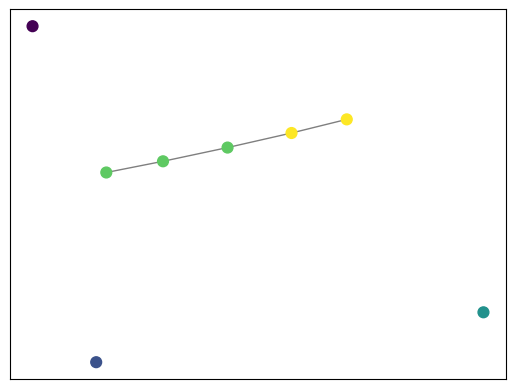

In [17]:
import community as community_louvain
import matplotlib.pyplot as plt
import matplotlib.cm as cm
# Community detectionm

#first compute the best partition
partition = community_louvain.best_partition(G1)

# draw the graph
pos1 = nx.circular_layout(G)
pos = nx.spring_layout(G)
# pos2 = nx.planar_layout(G)
# color the nodes according to their partition
cmap = cm.get_cmap('viridis', max(partition.values()) + 1)
nx.draw_networkx_nodes(G, pos, partition.keys(), node_size=60,
                       cmap=cmap, node_color=list(partition.values()))
nx.draw_networkx_edges(G, pos, alpha=0.5)
plt.show()

In [ ]:
from scipy import stats
import numpy as np

# Define two distributions
distribution1 = np.array([3, 1])
distribution2 = np.array([4])

# Calculate the Wasserstein distance
distance = stats.wasserstein_distance(distribution1, distribution2)

print(f"Wasserstein distance between the distributions: {distance}")

In [ ]:
import networkx as nx
import numpy as np
import ot

# Create a directed, weighted graph
G = nx.DiGraph()

# Add nodes and weighted edges
edges = [
    (0, 1, 3.0),
    (0, 2, 2.0),
    (1, 3, 4.0),
    (2, 3, 1.0)
]
G.add_weighted_edges_from(edges)

# Function to get the weight distribution for a node
def get_weight_distribution(G, node):
    weights = []
    for _, neighbor, data in G.out_edges(node, data=True):
        weights.append(data['weight'])
    return np.array(weights)

# Compute the Wasserstein distance between the distributions of edge weights for node pairs
node_pairs = [(0,1)]
for u, v in node_pairs:
    dist_u = get_weight_distribution(G, u)
    dist_v = get_weight_distribution(G, v)
    
    # Ensure the distributions have the same length by padding with zeros
    max_len = max(len(dist_u), len(dist_v))
    dist_u = np.pad(dist_u, (0, max_len - len(dist_u)), 'constant')
    dist_v = np.pad(dist_v, (0, max_len - len(dist_v)), 'constant')
    print(dist_u)
    print(dist_v)
    
    # Define uniform distributions
    a = np.ones(len(dist_u)) / len(dist_u)
    a= np.array([0.5, 0.5])
    print(a)
    b = np.ones(len(dist_v)) / len(dist_v)
    b= np.array([1.,0.])
    print(b)
    
    # Compute the cost matrix (Euclidean distance between weights)
    M = ot.dist(dist_u.reshape(-1, 1), dist_v.reshape(-1, 1), metric='euclidean')
    print(M)
    # Compute the Wasserstein distance
    wd = ot.emd2(a, b, M)
    
    print(f"Wasserstein distance between node {u} and node {v} distributions: {wd}")


